# Лабораторна робота №10
## Робота з незбалансованими вибірками

Дослідження методів класифікації на наборі Poker Hand. Рідкісні класи мають найбільші номери, тому додатково розглянемо бінарну задачу: класи 0–3 — звичайна комбінація, класи 4–9 — виграшна комбінація.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
data_dir = Path('data')
if not (data_dir / 'poker-hand-training-true.data').exists():
    data_dir = Path('lab10/data')
columns = ['Suit1','C1','Suit2','C2','Suit3','C3','Suit4','C4','Suit5','C5','CLASS']
df = pd.read_csv(data_dir / 'poker-hand-training-true.data', names=columns)
print('Розмір вибірки:', df.shape)
print('Розподіл класів (%):')
print((df['CLASS'].value_counts(normalize=True).sort_index() * 100).round(3))
display(df.head())

Розмір вибірки: (25010, 11)
Розподіл класів (%):
CLASS
0    49.952
1    42.379
2     4.822
3     2.051
4     0.372
5     0.216
6     0.144
7     0.024
8     0.020
9     0.020
Name: proportion, dtype: float64


,Suit1,C1,Suit2,C2,Suit3,C3,Suit4,C4,Suit5,C5,CLASS
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


In [3]:
suit_columns = ['Suit1','Suit2','Suit3','Suit4','Suit5']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_suits = encoder.fit_transform(df[suit_columns])
encoded_names = encoder.get_feature_names_out(suit_columns)
features = pd.concat([df.drop(columns=suit_columns + ['CLASS']).reset_index(drop=True), pd.DataFrame(encoded_suits, columns=encoded_names)], axis=1)
X = features.to_numpy()
y = df['CLASS'].to_numpy()
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
print('Після OHE кількість ознак:', X.shape[1])

Після OHE кількість ознак: 25


## Багатокласова класифікація

Спочатку оцінюємо звичайний Random Forest, а потім порівнюємо його з вагами класів та Extra Trees. Для рідкісних класів головною метрикою є `recall` і `F1`, а не лише accuracy.

In [4]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest balanced': RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees balanced': ExtraTreesClassifier(n_estimators=150, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print('\n' + name)
    print(classification_report(y_test, model.predict(X_test), zero_division=0))


Random Forest
              precision    recall  f1-score   support

           0       0.58      0.77      0.66      4997
           1       0.53      0.42      0.47      4240
           2       0.00      0.00      0.00       482
           3       1.00      0.00      0.01       205
           4       0.00      0.00      0.00        37
           5       0.00      0.00      0.00        22
           6       0.00      0.00      0.00        14
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2

    accuracy                           0.56     10004
   macro avg       0.21      0.12      0.11     10004
weighted avg       0.53      0.56      0.53     10004


Random Forest balanced
              precision    recall  f1-score   support

           0       0.57      0.76      0.65      4997
           1       0.50      0.38      0.44      4240
           2       0.00      0.00      

## Бінарна постановка задачі

Об’єднуємо класи 0–3 у клас `0` (без виграшної комбінації), а класи 4–9 — у клас `1` (виграшна комбінація).

In [5]:
binary_y = (y >= 4).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, binary_y, test_size=0.4, stratify=binary_y, random_state=RANDOM_STATE)
print('Розподіл бінарних класів (%):')
print((pd.Series(binary_y).value_counts(normalize=True).sort_index() * 100).round(3))

class SimpleBlaggingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=25, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError('Blagging підтримує тільки два класи')
        rng = np.random.RandomState(self.random_state)
        indices_by_class = [np.flatnonzero(y == c) for c in self.classes_]
        n_each = min(len(i) for i in indices_by_class)
        self.estimators_ = []
        for _ in range(self.n_estimators):
            selected = np.concatenate([rng.choice(i, n_each, replace=False) for i in indices_by_class])
            rng.shuffle(selected)
            tree = DecisionTreeClassifier(random_state=rng.randint(0, 2**31 - 1))
            tree.fit(np.asarray(X)[selected], y[selected])
            self.estimators_.append(tree)
        return self

    def predict_proba(self, X):
        return np.mean([tree.predict_proba(X) for tree in self.estimators_], axis=0)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

Розподіл бінарних класів (%):
0    99.204
1     0.796
Name: proportion, dtype: float64


In [6]:
binary_models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    'Blagging': SimpleBlaggingClassifier(n_estimators=25, random_state=RANDOM_STATE)
}
for name, model in binary_models.items():
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_test)[:, 1]
    print('\n' + name)
    print(classification_report(y_test, model.predict(X_test), target_names=['Звичайна', 'Виграшна'], zero_division=0))
    print('ROC-AUC:', round(roc_auc_score(y_test, probabilities), 4))


Random Forest
              precision    recall  f1-score   support

    Звичайна       0.99      1.00      1.00      9924
    Виграшна       0.00      0.00      0.00        80

    accuracy                           0.99     10004
   macro avg       0.50      0.50      0.50     10004
weighted avg       0.98      0.99      0.99     10004

ROC-AUC: 0.7736

Gradient Boosting
              precision    recall  f1-score   support

    Звичайна       0.99      1.00      1.00      9924
    Виграшна       1.00      0.01      0.02        80

    accuracy                           0.99     10004
   macro avg       1.00      0.51      0.51     10004
weighted avg       0.99      0.99      0.99     10004

ROC-AUC: 0.7639

Extra Trees
              precision    recall  f1-score   support

    Звичайна       0.99      1.00      1.00      9924
    Виграшна       0.88      0.26      0.40        80

    accuracy                           0.99     10004
   macro avg       0.93      0.63      0.70     1

## Порівняння ROC та Precision-Recall

ROC-AUC показує загальну здатність розділяти класи, а Average Precision краще відображає якість для незбалансованої позитивної групи.

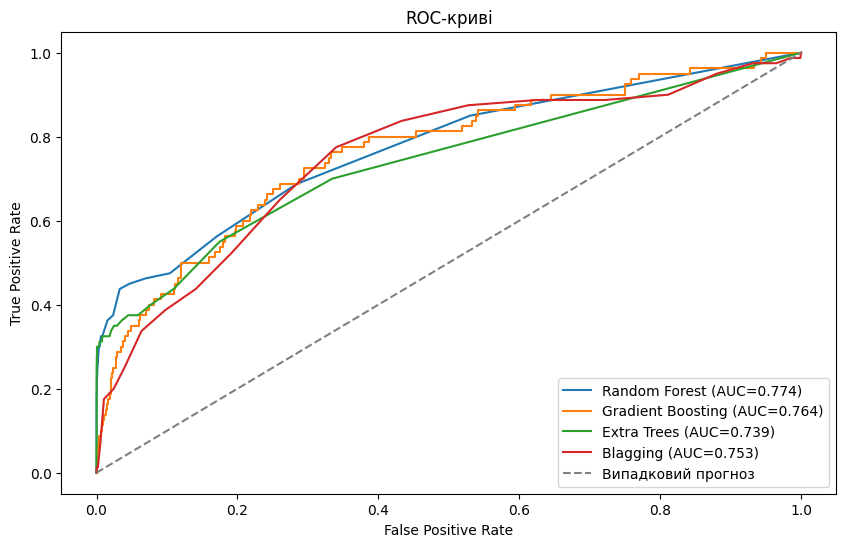

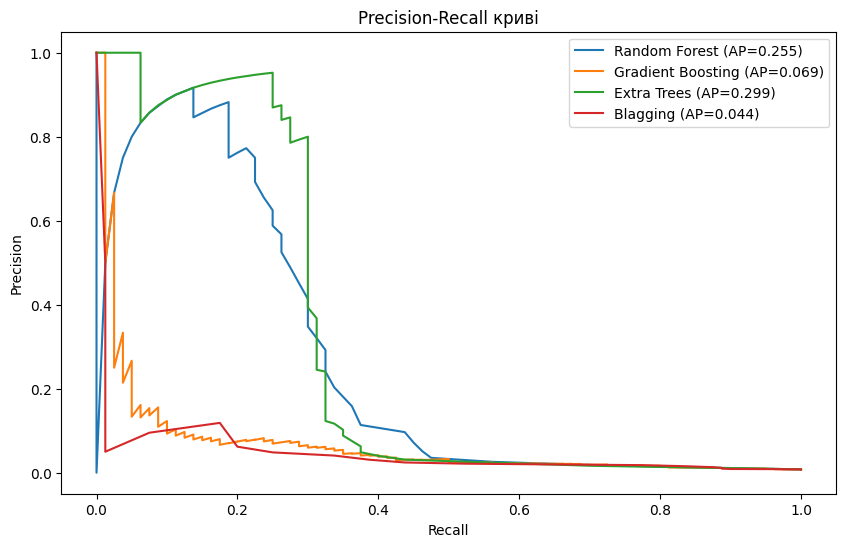

In [7]:
plt.figure(figsize=(10, 6))
for name, model in binary_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Випадковий прогноз')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-криві')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for name, model in binary_models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    ap = average_precision_score(y_test, probabilities)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall криві')
plt.legend()
plt.show()

## Методи повторної вибірки

Для запуску прикладів із `imbalanced-learn` встановіть бібліотеку: `python3 -m pip install --user imbalanced-learn`. Нижче порівнюються SMOTE та RandomOverSampler із Extra Trees.

In [8]:
try:
    from imblearn.pipeline import make_pipeline
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    sampling_methods = {
        'RandomOverSampler': RandomOverSampler(random_state=RANDOM_STATE),
        'SMOTE': SMOTE(random_state=RANDOM_STATE),
        'RandomUnderSampler': RandomUnderSampler(random_state=RANDOM_STATE)
    }
    for name, sampler in sampling_methods.items():
        pipeline = make_pipeline(sampler, ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_test)
        print('\n' + name)
        print(classification_report(y_test, prediction, target_names=['Звичайна', 'Виграшна'], zero_division=0))
except ImportError:
    print('imbalanced-learn не встановлено. Встановіть: python3 -m pip install --user imbalanced-learn')


RandomOverSampler
              precision    recall  f1-score   support

    Звичайна       0.99      1.00      1.00      9924
    Виграшна       0.91      0.26      0.41        80

    accuracy                           0.99     10004
   macro avg       0.95      0.63      0.70     10004
weighted avg       0.99      0.99      0.99     10004


SMOTE
              precision    recall  f1-score   support

    Звичайна       0.99      1.00      1.00      9924
    Виграшна       0.88      0.26      0.40        80

    accuracy                           0.99     10004
   macro avg       0.93      0.63      0.70     10004
weighted avg       0.99      0.99      0.99     10004


RandomUnderSampler
              precision    recall  f1-score   support

    Звичайна       0.99      0.64      0.78      9924
    Виграшна       0.01      0.59      0.03        80

    accuracy                           0.64     10004
   macro avg       0.50      0.61      0.40     10004
weighted avg       0.99     